In [92]:
import pandas as pd
import numpy as np
import keras
import warnings
warnings.filterwarnings(action="ignore")
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

%matplotlib inline

from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


from keras.applications.vgg19 import VGG19
from tensorflow.keras.applications import Xception

from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import TensorBoard,EarlyStopping

import sklearn.metrics as metrics
from keras.callbacks import LearningRateScheduler
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x, verbose=0)

In [93]:
import os
import pandas as pd

healthy_dirs = [
    r'/kaggle/input/osteoporosis-database/Osteoporosis Knee X-ray/normal',
    r'/kaggle/input/osteoporosis/osteoporosis/normal',
    r'/kaggle/input/osteoporosis-knee-dataset-preprocessed128x256/Osteoporosis Knee Dataset/Normal',
    r'/kaggle/input/osteoporosis-knee-xray-dataset/normal/normal'
]


osteoporosis_dirs = [
    r'/kaggle/input/osteoporosis-database/Osteoporosis Knee X-ray/osteoporosis',
    r'/kaggle/input/osteoporosis/osteoporosis/osteoporosis',
    r'/kaggle/input/osteoporosis-knee-dataset-preprocessed128x256/Osteoporosis Knee Dataset/Osteoporosis',
    r'/kaggle/input/osteoporosis-knee-xray-dataset/osteoporosis/osteoporosis'
]

filepaths = []
labels = []
dict_lists = [healthy_dirs, osteoporosis_dirs]
class_labels = ['Healthy', 'Osteoporosis']

for i, dir_list in enumerate(dict_lists):
    for j in dir_list:
        flist = os.listdir(j)
        for f in flist:
            fpath = os.path.join(j, f)
            filepaths.append(fpath)
            labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
knee_osteoporosis_data = pd.concat([Fseries, Lseries], axis=1)
knee_osteoporosis_df = pd.DataFrame(knee_osteoporosis_data)
print(knee_osteoporosis_df.head())
print(knee_osteoporosis_df["labels"].value_counts())

                                           filepaths   labels
0  /kaggle/input/osteoporosis-database/Osteoporos...  Healthy
1  /kaggle/input/osteoporosis-database/Osteoporos...  Healthy
2  /kaggle/input/osteoporosis-database/Osteoporos...  Healthy
3  /kaggle/input/osteoporosis-database/Osteoporos...  Healthy
4  /kaggle/input/osteoporosis-database/Osteoporos...  Healthy
labels
Osteoporosis    793
Healthy         780
Name: count, dtype: int64


In [94]:
train_images, test_images = train_test_split(knee_osteoporosis_df, test_size=0.3, random_state=42)
train_set, val_set = train_test_split(knee_osteoporosis_df, test_size=0.2, random_state=42)

In [95]:
print(train_set.shape)
print(test_images.shape)
print(val_set.shape)
print(train_images.shape)

(1258, 2)
(472, 2)
(315, 2)
(1101, 2)


In [96]:
# Data augmentation for the training set
train_image_gen = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=10,  # Limit rotation for X-ray images
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,  # Horizontal flip might be relevant
    vertical_flip=False,  # Vertical flip usually not relevant for X-rays
    brightness_range=[0.8, 1.2],  # Adjust brightness slightly
    fill_mode='nearest'
)

# Data generators for validation and test sets (no augmentation)
val_test_image_gen = ImageDataGenerator(
    preprocessing_function=keras.applications.mobilenet_v2.preprocess_input
)

# Flow from dataframe for training, validation, and test sets
train = train_image_gen.flow_from_dataframe(
    dataframe=train_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(224,224),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=4,
    shuffle=True
)

val = val_test_image_gen.flow_from_dataframe(
    dataframe=val_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(224,224),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=4,
    shuffle=False
)

test = val_test_image_gen.flow_from_dataframe(
    dataframe=test_images,
    x_col="filepaths",
    y_col="labels",
    target_size=(224,224),
    color_mode='rgb',
    class_mode="categorical",
    batch_size=4,
    shuffle=False
)

Found 1258 validated image filenames belonging to 2 classes.
Found 315 validated image filenames belonging to 2 classes.
Found 472 validated image filenames belonging to 2 classes.


In [97]:
classes=list(train.class_indices.keys())
print (classes)

['Healthy', 'Osteoporosis']


In [98]:
predictions = []

In [99]:
def show_knee_images(image_gen):
    test_dict = test.class_indices
    classes = list(test_dict.keys())
    images, labels=next(image_gen) # get a sample batch from the generator
    plt.figure(figsize=(20,20))
    length = len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5,5,i+1)
        image=(images[i]+1)/2 #scale images between 0 and 1
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color="green",fontsize=16)
        plt.axis('off')
    plt.show()

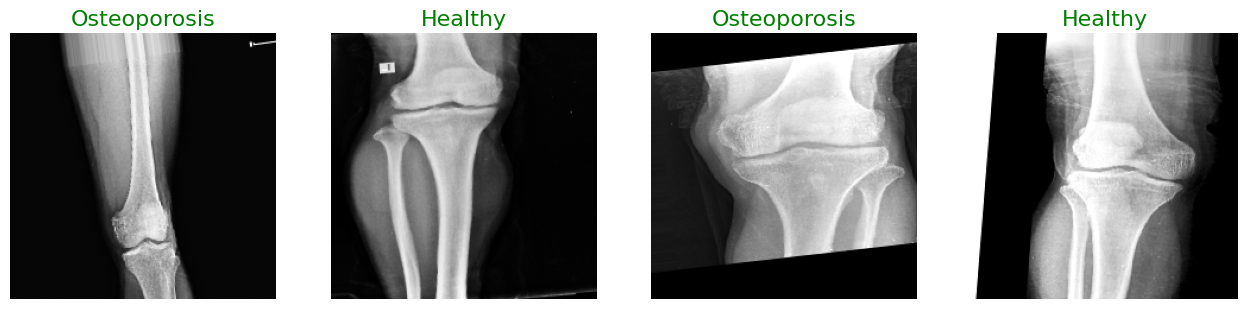

In [100]:
show_knee_images(train)

In [101]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, GlobalAveragePooling2D, BatchNormalization, SeparableConv2D
from keras.models import Model
from keras.applications import MobileNetV3Large
from keras.regularizers import l2
import tensorflow as tf

# Number of classes (2 for binary classification: normal and osteoporosis)
num_classes = 2

base_model = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
)

# Unfreeze some layers in the base model
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Adding more complex layers
x = Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(224, activation='relu', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation="softmax")(x)

# Create the custom model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.optimizers.Adam(learning_rate=0.0001),  # Lower learning rate
    metrics=['accuracy']
)

model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 111, 111,  │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 111, 111,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 111, 111,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 109, 109,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 109, 109,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 109, 109,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 109, 109,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 109, 109,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 109, 109,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 109, 109,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 109, 109,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 55, 55,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 55, 55,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 55, 55,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 55, 55,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 55, 55,    │          0 │ add_8[0][0]     

 Total params: 23,606,858 (90.05 MB)

 Trainable params: 23,548,810 (89.83 MB)

 Non-trainable params: 58,048 (226.75 KB)

In [102]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001
)

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_set['labels']),
    y=train_set['labels']
)

class_weights = dict(enumerate(class_weights))

# Early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [103]:
history = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 128s 226ms/step - accuracy: 0.5777 - loss: 24.1595 - val_accuracy: 0.5897 - val_loss: 22.9850 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7500 - loss: 22.9288 - val_accuracy: 0.6667 - val_loss: 23.0130 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.5492 - loss: 23.3581 - val_accuracy: 0.6410 - val_loss: 22.3114 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 431us/step - accuracy: 0.5000 - loss: 22.3411 - val_accuracy: 1.0000 - val_loss: 22.0300 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.6203 - loss: 22.5063 - val_accuracy: 0.6859 - val_loss: 21.6389 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.2500 - loss: 21.7230 - val_accuracy: 1.0000 - val_loss: 21.4995 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━

In [104]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.6633 - loss: 20.3835


[20.41126823425293, 0.6652542352676392]

In [177]:
history1 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9025 - loss: 0.2932 - val_accuracy: 0.9167 - val_loss: 0.2711 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 118us/step - accuracy: 1.0000 - loss: 0.0590 - val_accuracy: 1.0000 - val_loss: 0.1162 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.9120 - loss: 0.2522 - val_accuracy: 0.9167 - val_loss: 0.2683 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 133us/step - accuracy: 1.0000 - loss: 0.1239 - val_accuracy: 1.0000 - val_loss: 0.0855 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.8791 - loss: 0.3177 - val_accuracy: 0.9199 - val_loss: 0.2601 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 100us/step - accuracy: 0.7500 - loss: 0.4059 - val_accuracy: 1.0000 - val_loss: 0.1534 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms

In [178]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9122 - loss: 0.2807


[0.23775748908519745, 0.930084764957428]

In [107]:
history2 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.6463 - loss: 16.7417 - val_accuracy: 0.7115 - val_loss: 15.9359 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step - accuracy: 0.7500 - loss: 15.9488 - val_accuracy: 1.0000 - val_loss: 15.8138 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.5939 - loss: 14.4998 - val_accuracy: 0.7115 - val_loss: 13.6684 - learning_rate: 1.0000e-04
Epoch 8/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - accuracy: 0.7500 - loss: 13.6198 - val_accuracy: 1.0000 - val_loss: 13.3243 - learning_rate: 1.0000e-04
Epoch 9/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.6022 - loss: 13.7241 - val_accuracy: 0.5769 - val_loss: 13.0712 - learning_rate: 1.0000e-04
Epoch 10/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 521us/step - accuracy: 1.0000 - loss: 12.6326 - val_accuracy: 0.6667 - val_loss: 12.9415 - learning_rate: 1.0000e-04


In [108]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.5578 - loss: 13.0972


[13.085742950439453, 0.5677965879440308]

In [109]:
history3 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.6062 - loss: 12.9543 - val_accuracy: 0.7019 - val_loss: 12.1958 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 0.5000 - loss: 12.8130 - val_accuracy: 1.0000 - val_loss: 11.8163 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.6160 - loss: 12.1400 - val_accuracy: 0.7051 - val_loss: 11.4169 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.7500 - loss: 11.6377 - val_accuracy: 1.0000 - val_loss: 11.1461 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.6567 - loss: 11.3394 - val_accuracy: 0.6346 - val_loss: 10.6585 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.5000 - loss: 11.0130 - val_accuracy: 0.6667 - val_loss: 10.5475 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━

In [110]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.6331 - loss: 9.1729


[9.160954475402832, 0.6483050584793091]

In [111]:
history4 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - accuracy: 0.6166 - loss: 9.1143 - val_accuracy: 0.6346 - val_loss: 8.5327 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 123us/step - accuracy: 0.5000 - loss: 8.6288 - val_accuracy: 0.6667 - val_loss: 8.9863 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.6689 - loss: 7.6766 - val_accuracy: 0.7244 - val_loss: 7.0620 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step - accuracy: 0.2500 - loss: 7.8768 - val_accuracy: 1.0000 - val_loss: 7.0165 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.6767 - loss: 7.0060 - val_accuracy: 0.7147 - val_loss: 6.4916 - learning_rate: 1.0000e-04
Epoch 8/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.5000 - loss: 7.0955 - val_accuracy: 1.0000 - val_loss: 6.2307 - learning_rate: 1.0000e-04
Epoch 9/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms

In [112]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7367 - loss: 6.0380


[6.0103559494018555, 0.7542372941970825]

In [113]:
history5 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - accuracy: 0.6560 - loss: 5.9660 - val_accuracy: 0.7212 - val_loss: 5.4745 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - accuracy: 0.7500 - loss: 5.5550 - val_accuracy: 1.0000 - val_loss: 5.2380 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.7200 - loss: 5.4753 - val_accuracy: 0.7244 - val_loss: 5.0784 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - accuracy: 0.2500 - loss: 5.4183 - val_accuracy: 1.0000 - val_loss: 5.0626 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - accuracy: 0.6526 - loss: 5.1461 - val_accuracy: 0.7372 - val_loss: 4.6923 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 118us/step - accuracy: 0.7500 - loss: 4.8474 - val_accuracy: 0.0000e+00 - val_loss: 5.1994 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 1

In [114]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7555 - loss: 4.1036


[4.111626625061035, 0.7542372941970825]

In [115]:
history6 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.7161 - loss: 4.1828 - val_accuracy: 0.7404 - val_loss: 3.9148 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 441us/step - accuracy: 0.5000 - loss: 4.0948 - val_accuracy: 1.0000 - val_loss: 3.7812 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.6746 - loss: 3.9874 - val_accuracy: 0.7500 - val_loss: 3.6829 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 464us/step - accuracy: 0.5000 - loss: 4.1441 - val_accuracy: 1.0000 - val_loss: 3.6005 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.6930 - loss: 3.7423 - val_accuracy: 0.7019 - val_loss: 3.4946 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 476us/step - accuracy: 0.5000 - loss: 3.8890 - val_accuracy: 1.0000 - val_loss: 3.3419 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms

In [116]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7365 - loss: 3.0391


[3.0484931468963623, 0.741525411605835]

In [117]:
history7 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.6721 - loss: 3.1269 - val_accuracy: 0.7596 - val_loss: 2.8844 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 451us/step - accuracy: 0.5000 - loss: 2.9558 - val_accuracy: 1.0000 - val_loss: 2.8178 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.7069 - loss: 2.9029 - val_accuracy: 0.7788 - val_loss: 2.6844 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 1.0000 - loss: 2.4747 - val_accuracy: 0.6667 - val_loss: 2.6122 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.7228 - loss: 2.7294 - val_accuracy: 0.7500 - val_loss: 2.5710 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.5000 - loss: 2.5348 - val_accuracy: 0.6667 - val_loss: 2.4866 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms

In [118]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.7621 - loss: 2.2685


[2.238093852996826, 0.7817796468734741]

In [119]:
history8 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.7477 - loss: 2.2901 - val_accuracy: 0.7724 - val_loss: 2.1334 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - accuracy: 1.0000 - loss: 1.8834 - val_accuracy: 1.0000 - val_loss: 1.8702 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms/step - accuracy: 0.7348 - loss: 2.1531 - val_accuracy: 0.8013 - val_loss: 1.9277 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step - accuracy: 0.7500 - loss: 2.1995 - val_accuracy: 1.0000 - val_loss: 1.7359 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.7488 - loss: 2.0137 - val_accuracy: 0.7692 - val_loss: 1.8422 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 116us/step - accuracy: 0.7500 - loss: 1.9071 - val_accuracy: 0.6667 - val_loss: 1.9431 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms

In [120]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8071 - loss: 1.6394


[1.649994134902954, 0.7881355881690979]

In [121]:
history9 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.7494 - loss: 1.6873 - val_accuracy: 0.7083 - val_loss: 1.6011 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - accuracy: 0.5000 - loss: 2.1763 - val_accuracy: 1.0000 - val_loss: 1.4883 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.7363 - loss: 1.6081 - val_accuracy: 0.8173 - val_loss: 1.4576 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 125us/step - accuracy: 0.7500 - loss: 1.3633 - val_accuracy: 0.6667 - val_loss: 1.5403 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.7912 - loss: 1.4729 - val_accuracy: 0.8333 - val_loss: 1.3180 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.7500 - loss: 1.3879 - val_accuracy: 1.0000 - val_loss: 1.2814 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms

In [122]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.7657 - loss: 1.2704


[1.2518904209136963, 0.7923728823661804]

In [123]:
history10 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.7318 - loss: 1.3513 - val_accuracy: 0.8013 - val_loss: 1.1366 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.7500 - loss: 1.3154 - val_accuracy: 1.0000 - val_loss: 1.0723 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.7471 - loss: 1.2519 - val_accuracy: 0.8077 - val_loss: 1.1590 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.7500 - loss: 1.1260 - val_accuracy: 1.0000 - val_loss: 0.8615 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.7632 - loss: 1.1592 - val_accuracy: 0.7853 - val_loss: 1.0627 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 129us/step - accuracy: 1.0000 - loss: 0.9088 - val_accuracy: 1.0000 - val_loss: 1.0201 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms

In [124]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8075 - loss: 0.9691


[0.9392608404159546, 0.8262711763381958]

In [125]:
history11 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - accuracy: 0.7954 - loss: 1.0089 - val_accuracy: 0.8141 - val_loss: 0.9110 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 127us/step - accuracy: 1.0000 - loss: 0.7570 - val_accuracy: 1.0000 - val_loss: 0.8653 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.7782 - loss: 0.9707 - val_accuracy: 0.8173 - val_loss: 0.8565 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 487us/step - accuracy: 0.7500 - loss: 0.7986 - val_accuracy: 1.0000 - val_loss: 0.7648 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.8032 - loss: 0.8966 - val_accuracy: 0.8141 - val_loss: 0.7576 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 1.0000 - loss: 0.6606 - val_accuracy: 1.0000 - val_loss: 0.6726 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms

In [126]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.7984 - loss: 0.7580


[0.7071832418441772, 0.8326271176338196]

In [127]:
history12 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.7721 - loss: 0.8227 - val_accuracy: 0.8269 - val_loss: 0.6735 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - accuracy: 0.7500 - loss: 1.4258 - val_accuracy: 1.0000 - val_loss: 0.4968 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.8253 - loss: 0.7231 - val_accuracy: 0.8462 - val_loss: 0.6293 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 135us/step - accuracy: 0.7500 - loss: 1.0036 - val_accuracy: 1.0000 - val_loss: 0.5800 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - accuracy: 0.8076 - loss: 0.7052 - val_accuracy: 0.8333 - val_loss: 0.6308 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step - accuracy: 0.7500 - loss: 0.5538 - val_accuracy: 1.0000 - val_loss: 0.4475 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms

In [128]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8318 - loss: 0.5387


[0.5163880586624146, 0.8474576473236084]

In [129]:
history12 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - accuracy: 0.8375 - loss: 0.6006 - val_accuracy: 0.8718 - val_loss: 0.4665 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 112us/step - accuracy: 0.5000 - loss: 1.3706 - val_accuracy: 1.0000 - val_loss: 0.3445 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.8430 - loss: 0.5604 - val_accuracy: 0.8718 - val_loss: 0.4505 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 1.0000 - loss: 0.3380 - val_accuracy: 1.0000 - val_loss: 0.2806 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.8496 - loss: 0.5438 - val_accuracy: 0.8846 - val_loss: 0.4731 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 115us/step - accuracy: 0.7500 - loss: 0.9922 - val_accuracy: 1.0000 - val_loss: 0.3546 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms

In [130]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8716 - loss: 0.4064


[0.3754420876502991, 0.8983050584793091]

In [131]:
history13 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.8565 - loss: 0.4953 - val_accuracy: 0.8269 - val_loss: 0.4891 - learning_rate: 1.0000e-04
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 123us/step - accuracy: 1.0000 - loss: 0.3884 - val_accuracy: 0.6667 - val_loss: 0.5826 - learning_rate: 1.0000e-04
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.8789 - loss: 0.4545 - val_accuracy: 0.8686 - val_loss: 0.4281 - learning_rate: 1.0000e-04
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 125us/step - accuracy: 0.7500 - loss: 0.5208 - val_accuracy: 1.0000 - val_loss: 0.2844 - learning_rate: 1.0000e-04
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.8665 - loss: 0.4608 - val_accuracy: 0.8814 - val_loss: 0.4001 - learning_rate: 1.0000e-04
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 110us/step - accuracy: 1.0000 - loss: 0.2031 - val_accuracy: 0.6667 - val_loss: 0.7940 - learning_rate: 1.0000e-04
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms

In [132]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8353 - loss: 0.4838


[0.4644097685813904, 0.8432203531265259]

In [133]:
history14 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.8481 - loss: 0.5134 - val_accuracy: 0.8718 - val_loss: 0.4004 - learning_rate: 2.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 111us/step - accuracy: 1.0000 - loss: 0.2603 - val_accuracy: 0.6667 - val_loss: 0.5619 - learning_rate: 2.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.8700 - loss: 0.4936 - val_accuracy: 0.9038 - val_loss: 0.3786 - learning_rate: 2.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 121us/step - accuracy: 0.7500 - loss: 0.3564 - val_accuracy: 1.0000 - val_loss: 0.3330 - learning_rate: 2.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.8810 - loss: 0.4448 - val_accuracy: 0.8910 - val_loss: 0.3895 - learning_rate: 2.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.7500 - loss: 0.7275 - val_accuracy: 1.0000 - val_loss: 0.2247 - learning_rate: 2.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms

In [134]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.8737 - loss: 0.4111


[0.3615746796131134, 0.9110169410705566]

In [135]:
history15 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9030 - loss: 0.4214 - val_accuracy: 0.8878 - val_loss: 0.3605 - learning_rate: 2.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - accuracy: 0.5000 - loss: 1.4230 - val_accuracy: 1.0000 - val_loss: 0.2097 - learning_rate: 2.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.8874 - loss: 0.4392 - val_accuracy: 0.8974 - val_loss: 0.3507 - learning_rate: 2.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 122us/step - accuracy: 1.0000 - loss: 0.2360 - val_accuracy: 1.0000 - val_loss: 0.2202 - learning_rate: 2.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.8894 - loss: 0.4691 - val_accuracy: 0.8974 - val_loss: 0.3600 - learning_rate: 2.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 461us/step - accuracy: 1.0000 - loss: 0.1701 - val_accuracy: 1.0000 - val_loss: 0.2012 - learning_rate: 2.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms

In [136]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8821 - loss: 0.3851


[0.3415885865688324, 0.9067796468734741]

In [137]:
history16 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.8985 - loss: 0.3997 - val_accuracy: 0.8910 - val_loss: 0.3373 - learning_rate: 2.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 109us/step - accuracy: 1.0000 - loss: 0.1826 - val_accuracy: 1.0000 - val_loss: 0.2132 - learning_rate: 2.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8842 - loss: 0.4112 - val_accuracy: 0.8910 - val_loss: 0.3308 - learning_rate: 2.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 117us/step - accuracy: 1.0000 - loss: 0.2039 - val_accuracy: 1.0000 - val_loss: 0.3249 - learning_rate: 2.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.9156 - loss: 0.3730 - val_accuracy: 0.8974 - val_loss: 0.3402 - learning_rate: 2.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - accuracy: 0.7500 - loss: 0.3894 - val_accuracy: 1.0000 - val_loss: 0.1997 - learning_rate: 2.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms

In [138]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8939 - loss: 0.3248


[0.2961406707763672, 0.9110169410705566]

In [139]:
history17 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.8943 - loss: 0.3953 - val_accuracy: 0.8846 - val_loss: 0.3218 - learning_rate: 2.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 106us/step - accuracy: 1.0000 - loss: 0.2061 - val_accuracy: 1.0000 - val_loss: 0.1999 - learning_rate: 2.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.9003 - loss: 0.3982 - val_accuracy: 0.8910 - val_loss: 0.3173 - learning_rate: 2.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 113us/step - accuracy: 1.0000 - loss: 0.1909 - val_accuracy: 1.0000 - val_loss: 0.2183 - learning_rate: 2.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.8940 - loss: 0.4054 - val_accuracy: 0.8942 - val_loss: 0.3268 - learning_rate: 2.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 121us/step - accuracy: 0.5000 - loss: 1.0123 - val_accuracy: 1.0000 - val_loss: 0.2181 - learning_rate: 2.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 117ms

In [140]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.8969 - loss: 0.3231


[0.2890767455101013, 0.9152542352676392]

In [141]:
history18 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.9037 - loss: 0.3421 - val_accuracy: 0.9071 - val_loss: 0.3115 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 125us/step - accuracy: 0.7500 - loss: 0.5394 - val_accuracy: 1.0000 - val_loss: 0.1743 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.8873 - loss: 0.3978 - val_accuracy: 0.9103 - val_loss: 0.3046 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 114us/step - accuracy: 1.0000 - loss: 0.3410 - val_accuracy: 1.0000 - val_loss: 0.1854 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - accuracy: 0.9128 - loss: 0.3633 - val_accuracy: 0.9071 - val_loss: 0.2992 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step - accuracy: 0.5000 - loss: 1.2455 - val_accuracy: 1.0000 - val_loss: 0.1579 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms

In [142]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9023 - loss: 0.3135


[0.2756616175174713, 0.9237288236618042]

In [143]:
history19 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9016 - loss: 0.3603 - val_accuracy: 0.9006 - val_loss: 0.3035 - learning_rate: 1.0000e-05
Epoch 8/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 117us/step - accuracy: 0.7500 - loss: 0.3405 - val_accuracy: 1.0000 - val_loss: 0.1807 - learning_rate: 1.0000e-05
Epoch 9/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9103 - loss: 0.3571 - val_accuracy: 0.9135 - val_loss: 0.2961 - learning_rate: 1.0000e-05
Epoch 10/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 112us/step - accuracy: 1.0000 - loss: 0.2232 - val_accuracy: 1.0000 - val_loss: 0.1631 - learning_rate: 1.0000e-05


In [144]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9010 - loss: 0.3154


[0.28289759159088135, 0.9216101765632629]

In [145]:
history20 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8872 - loss: 0.4060 - val_accuracy: 0.9038 - val_loss: 0.2965 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 116us/step - accuracy: 0.5000 - loss: 1.2050 - val_accuracy: 1.0000 - val_loss: 0.1675 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9066 - loss: 0.3615 - val_accuracy: 0.9006 - val_loss: 0.2999 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 111us/step - accuracy: 1.0000 - loss: 0.1940 - val_accuracy: 1.0000 - val_loss: 0.1763 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.8778 - loss: 0.4196 - val_accuracy: 0.9038 - val_loss: 0.3023 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 114us/step - accuracy: 0.7500 - loss: 1.5374 - val_accuracy: 1.0000 - val_loss: 0.1683 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms

In [146]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.8885 - loss: 0.3326


[0.2808450162410736, 0.9152542352676392]

In [147]:
history21 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.9242 - loss: 0.3285 - val_accuracy: 0.9038 - val_loss: 0.2831 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 1.0000 - loss: 0.1003 - val_accuracy: 1.0000 - val_loss: 0.1461 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.9085 - loss: 0.3480 - val_accuracy: 0.9038 - val_loss: 0.2933 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 491us/step - accuracy: 1.0000 - loss: 0.1915 - val_accuracy: 1.0000 - val_loss: 0.1362 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.8939 - loss: 0.3790 - val_accuracy: 0.9071 - val_loss: 0.3128 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 1.0000 - loss: 0.1084 - val_accuracy: 1.0000 - val_loss: 0.1288 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms

In [148]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9006 - loss: 0.3351


[0.28495344519615173, 0.9216101765632629]

In [149]:
history22 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.9105 - loss: 0.3545 - val_accuracy: 0.9071 - val_loss: 0.2878 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - accuracy: 0.7500 - loss: 1.2873 - val_accuracy: 1.0000 - val_loss: 0.1194 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.9145 - loss: 0.3036 - val_accuracy: 0.9103 - val_loss: 0.2764 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 124us/step - accuracy: 1.0000 - loss: 0.1759 - val_accuracy: 1.0000 - val_loss: 0.1262 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.9189 - loss: 0.3291 - val_accuracy: 0.9135 - val_loss: 0.2771 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 113us/step - accuracy: 1.0000 - loss: 0.0925 - val_accuracy: 1.0000 - val_loss: 0.1356 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms

In [150]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9045 - loss: 0.3085


[0.2587454617023468, 0.9258474707603455]

In [151]:
history23 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.9097 - loss: 0.3731 - val_accuracy: 0.9167 - val_loss: 0.2905 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 127us/step - accuracy: 1.0000 - loss: 0.1639 - val_accuracy: 1.0000 - val_loss: 0.1307 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.9075 - loss: 0.3448 - val_accuracy: 0.9071 - val_loss: 0.2767 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 110us/step - accuracy: 1.0000 - loss: 0.1607 - val_accuracy: 1.0000 - val_loss: 0.1515 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.9154 - loss: 0.3330 - val_accuracy: 0.9071 - val_loss: 0.2775 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 1.0000 - loss: 0.1959 - val_accuracy: 1.0000 - val_loss: 0.1082 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms

In [152]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9006 - loss: 0.3056


[0.24973009526729584, 0.9258474707603455]

In [153]:
history24 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.9242 - loss: 0.3048 - val_accuracy: 0.9135 - val_loss: 0.2647 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 115us/step - accuracy: 1.0000 - loss: 0.0935 - val_accuracy: 1.0000 - val_loss: 0.1569 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8822 - loss: 0.3905 - val_accuracy: 0.9167 - val_loss: 0.2741 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 108us/step - accuracy: 1.0000 - loss: 0.1463 - val_accuracy: 1.0000 - val_loss: 0.1342 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9130 - loss: 0.3338 - val_accuracy: 0.9103 - val_loss: 0.2763 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 112us/step - accuracy: 1.0000 - loss: 0.0817 - val_accuracy: 1.0000 - val_loss: 0.1277 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms

In [154]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9057 - loss: 0.2821


[0.2409912347793579, 0.930084764957428]

In [155]:
history25 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.8936 - loss: 0.3630 - val_accuracy: 0.9135 - val_loss: 0.2848 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 122us/step - accuracy: 0.5000 - loss: 1.3938 - val_accuracy: 1.0000 - val_loss: 0.1825 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9102 - loss: 0.3520 - val_accuracy: 0.9167 - val_loss: 0.2847 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 117us/step - accuracy: 0.7500 - loss: 0.3240 - val_accuracy: 1.0000 - val_loss: 0.1504 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.9160 - loss: 0.3054 - val_accuracy: 0.9135 - val_loss: 0.2764 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 108us/step - accuracy: 1.0000 - loss: 0.0910 - val_accuracy: 1.0000 - val_loss: 0.1480 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms

In [156]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9030 - loss: 0.3030


[0.2615129053592682, 0.9237288236618042]

In [157]:
history26 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9243 - loss: 0.2935 - val_accuracy: 0.9135 - val_loss: 0.3156 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 126us/step - accuracy: 1.0000 - loss: 0.0715 - val_accuracy: 1.0000 - val_loss: 0.1258 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.8948 - loss: 0.3682 - val_accuracy: 0.9103 - val_loss: 0.2957 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 140us/step - accuracy: 1.0000 - loss: 0.0869 - val_accuracy: 1.0000 - val_loss: 0.1140 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9227 - loss: 0.3004 - val_accuracy: 0.9038 - val_loss: 0.2751 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 106us/step - accuracy: 1.0000 - loss: 0.1596 - val_accuracy: 1.0000 - val_loss: 0.1244 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms

In [158]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9125 - loss: 0.2924


[0.23774439096450806, 0.930084764957428]

In [159]:
history27 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8958 - loss: 0.3260 - val_accuracy: 0.9038 - val_loss: 0.2787 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 440us/step - accuracy: 1.0000 - loss: 0.0636 - val_accuracy: 1.0000 - val_loss: 0.0973 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 114ms/step - accuracy: 0.8876 - loss: 0.3196 - val_accuracy: 0.9167 - val_loss: 0.2824 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 106us/step - accuracy: 1.0000 - loss: 0.1278 - val_accuracy: 1.0000 - val_loss: 0.1105 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9004 - loss: 0.3110 - val_accuracy: 0.9071 - val_loss: 0.2820 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 103us/step - accuracy: 0.7500 - loss: 0.3047 - val_accuracy: 1.0000 - val_loss: 0.1173 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms

In [160]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.8984 - loss: 0.3035


[0.24377723038196564, 0.9237288236618042]

In [161]:
history28 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9162 - loss: 0.2982 - val_accuracy: 0.9135 - val_loss: 0.2831 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 115us/step - accuracy: 0.7500 - loss: 0.2888 - val_accuracy: 1.0000 - val_loss: 0.1026 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.8997 - loss: 0.3425 - val_accuracy: 0.9167 - val_loss: 0.2739 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 444us/step - accuracy: 0.5000 - loss: 1.0146 - val_accuracy: 1.0000 - val_loss: 0.0915 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 116ms/step - accuracy: 0.9030 - loss: 0.3209 - val_accuracy: 0.9071 - val_loss: 0.2963 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 427us/step - accuracy: 1.0000 - loss: 0.0737 - val_accuracy: 1.0000 - val_loss: 0.0899 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms

In [162]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9094 - loss: 0.2937


[0.24092808365821838, 0.9279661178588867]

In [163]:
history29 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9147 - loss: 0.2664 - val_accuracy: 0.9167 - val_loss: 0.2691 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step - accuracy: 1.0000 - loss: 0.0780 - val_accuracy: 1.0000 - val_loss: 0.0825 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.9226 - loss: 0.2597 - val_accuracy: 0.9199 - val_loss: 0.2691 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 109us/step - accuracy: 1.0000 - loss: 0.1196 - val_accuracy: 1.0000 - val_loss: 0.0932 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.8998 - loss: 0.3065 - val_accuracy: 0.9135 - val_loss: 0.2588 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 111us/step - accuracy: 1.0000 - loss: 0.1413 - val_accuracy: 1.0000 - val_loss: 0.1214 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms

In [164]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9073 - loss: 0.3013


[0.24080227315425873, 0.930084764957428]

In [165]:
history30 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.9049 - loss: 0.2818 - val_accuracy: 0.9071 - val_loss: 0.2584 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 122us/step - accuracy: 0.7500 - loss: 0.3743 - val_accuracy: 1.0000 - val_loss: 0.0904 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9206 - loss: 0.2815 - val_accuracy: 0.9135 - val_loss: 0.2737 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 123us/step - accuracy: 1.0000 - loss: 0.1379 - val_accuracy: 1.0000 - val_loss: 0.1121 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8856 - loss: 0.3202 - val_accuracy: 0.9103 - val_loss: 0.2652 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 117us/step - accuracy: 1.0000 - loss: 0.1553 - val_accuracy: 1.0000 - val_loss: 0.0992 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms

In [166]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.8937 - loss: 0.2880


[0.2280595451593399, 0.9194915294647217]

In [167]:
history31 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.9088 - loss: 0.2980 - val_accuracy: 0.9135 - val_loss: 0.2737 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 118us/step - accuracy: 0.7500 - loss: 0.3398 - val_accuracy: 1.0000 - val_loss: 0.0881 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.9222 - loss: 0.2479 - val_accuracy: 0.9167 - val_loss: 0.2624 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 117us/step - accuracy: 0.5000 - loss: 0.9823 - val_accuracy: 1.0000 - val_loss: 0.1105 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9198 - loss: 0.2454 - val_accuracy: 0.9167 - val_loss: 0.2706 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 108us/step - accuracy: 1.0000 - loss: 0.1127 - val_accuracy: 1.0000 - val_loss: 0.1034 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms

In [168]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9089 - loss: 0.2991


[0.2362794429063797, 0.9279661178588867]

In [169]:
history32 = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    validation_data=val,
    validation_steps=val.samples // val.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.8958 - loss: 0.3072 - val_accuracy: 0.9199 - val_loss: 0.2589 - learning_rate: 1.0000e-05
Epoch 2/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 113us/step - accuracy: 1.0000 - loss: 0.1303 - val_accuracy: 1.0000 - val_loss: 0.0827 - learning_rate: 1.0000e-05
Epoch 3/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 111ms/step - accuracy: 0.9062 - loss: 0.3008 - val_accuracy: 0.9199 - val_loss: 0.2544 - learning_rate: 1.0000e-05
Epoch 4/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 118us/step - accuracy: 1.0000 - loss: 0.0662 - val_accuracy: 1.0000 - val_loss: 0.1056 - learning_rate: 1.0000e-05
Epoch 5/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms/step - accuracy: 0.9131 - loss: 0.2687 - val_accuracy: 0.9038 - val_loss: 0.2514 - learning_rate: 1.0000e-05
Epoch 6/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 117us/step - accuracy: 1.0000 - loss: 0.0736 - val_accuracy: 1.0000 - val_loss: 0.1498 - learning_rate: 1.0000e-05
Epoch 7/10
314/314 ━━━━━━━━━━━━━━━━━━━━ 36s 112ms

In [170]:
model.evaluate(test, steps=test.samples // test.batch_size)

118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9137 - loss: 0.2787


[0.22733750939369202, 0.9385592937469482]

In [171]:
pred = model.predict(test)
pred = np.argmax(pred, axis=1) #pick class with highest  probability

labels = (train.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred2 = [labels[k] for k in pred]

y_test = test_images.labels # set y_test to the expected output
print(classification_report(y_test, pred2))
print("Accuracy of the Model:","{:.1f}%".format(accuracy_score(y_test, pred2)*100))

118/118 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step
              precision    recall  f1-score   support

     Healthy       0.95      0.92      0.94       231
Osteoporosis       0.92      0.96      0.94       241

    accuracy                           0.94       472
   macro avg       0.94      0.94      0.94       472
weighted avg       0.94      0.94      0.94       472

Accuracy of the Model: 93.9%


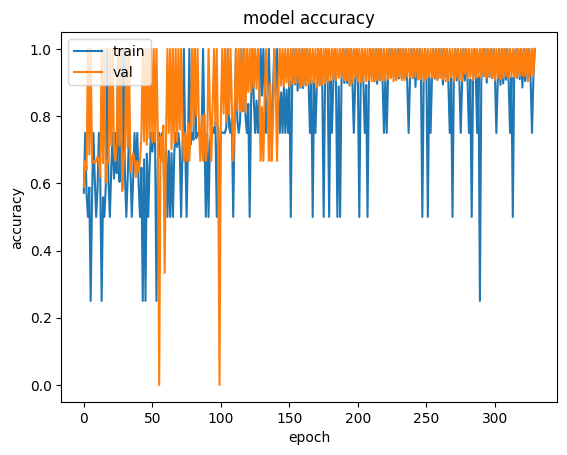

In [172]:
plt.plot(history.history["accuracy"] +
history1.history["accuracy"] +
history2.history["accuracy"] +
history3.history["accuracy"] +
history4.history["accuracy"] +
history5.history["accuracy"] +
history6.history["accuracy"] +
history7.history["accuracy"] +
history8.history["accuracy"] +
history9.history["accuracy"] +
history10.history["accuracy"] +
history11.history["accuracy"] +
history12.history["accuracy"] +
history13.history["accuracy"] +
history14.history["accuracy"] +
history15.history["accuracy"] +
history16.history["accuracy"] +
history17.history["accuracy"] +
history18.history["accuracy"] +
history19.history["accuracy"] +
history20.history["accuracy"] +
history21.history["accuracy"] +
history22.history["accuracy"] +
history23.history["accuracy"] +
history24.history["accuracy"] +
history25.history["accuracy"] +
history26.history["accuracy"] +
history27.history["accuracy"] +
history28.history["accuracy"] +
history29.history["accuracy"] +
history30.history["accuracy"] +
history31.history["accuracy"] +
history32.history["accuracy"])



plt.plot(history.history["val_accuracy"] +
history1.history["val_accuracy"] +
history2.history["val_accuracy"] +
history3.history["val_accuracy"] +
history4.history["val_accuracy"] +
history5.history["val_accuracy"] +
history6.history["val_accuracy"] +
history7.history["val_accuracy"] +
history8.history["val_accuracy"] +
history9.history["val_accuracy"] +
history10.history["val_accuracy"] +
history11.history["val_accuracy"] +
history12.history["val_accuracy"] +
history13.history["val_accuracy"] +
history14.history["val_accuracy"] +
history15.history["val_accuracy"] +
history16.history["val_accuracy"] +
history17.history["val_accuracy"] +
history18.history["val_accuracy"] +
history19.history["val_accuracy"] +
history20.history["val_accuracy"] +
history21.history["val_accuracy"] +
history22.history["val_accuracy"] +
history23.history["val_accuracy"] +
history24.history["val_accuracy"] +
history25.history["val_accuracy"] +
history26.history["val_accuracy"] +
history27.history["val_accuracy"] +
history28.history["val_accuracy"] +
history29.history["val_accuracy"] +
history30.history["val_accuracy"] +
history31.history["val_accuracy"] +
history32.history["val_accuracy"])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

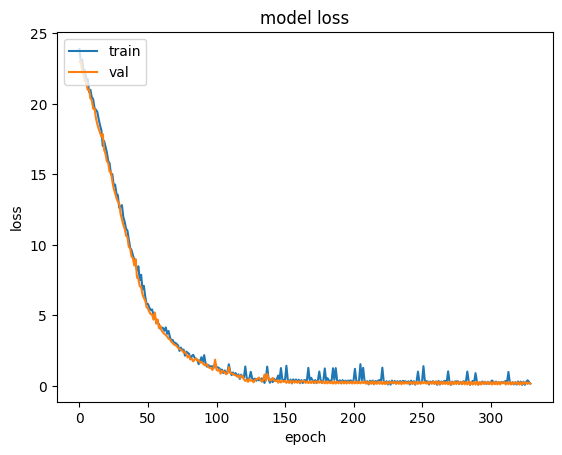

In [173]:
plt.plot(history.history["loss"] +
history1.history["loss"] +
history2.history["loss"] +
history3.history["loss"] +
history4.history["loss"] +
history5.history["loss"] +
history6.history["loss"] +
history7.history["loss"] +
history8.history["loss"] +
history9.history["loss"] +
history10.history["loss"] +
history11.history["loss"] +
history12.history["loss"] +
history13.history["loss"] +
history14.history["loss"] +
history15.history["loss"] +
history16.history["loss"] +
history17.history["loss"] +
history18.history["loss"] +
history19.history["loss"] +
history20.history["loss"] +
history21.history["loss"] +
history22.history["loss"] +
history23.history["loss"] +
history24.history["loss"] +
history25.history["loss"] +
history26.history["loss"] +
history27.history["loss"] +
history28.history["loss"] +
history29.history["loss"] +
history30.history["loss"] +
history31.history["loss"] +
history32.history["loss"])


plt.plot(history.history["val_loss"] +
history1.history["val_loss"] +
history2.history["val_loss"] +
history3.history["val_loss"] +
history4.history["val_loss"] +
history5.history["val_loss"] +
history6.history["val_loss"] +
history7.history["val_loss"] +
history8.history["val_loss"] +
history9.history["val_loss"] +
history10.history["val_loss"] +
history11.history["val_loss"] +
history12.history["val_loss"] +
history13.history["val_loss"] +
history14.history["val_loss"] +
history15.history["val_loss"] +
history16.history["val_loss"] +
history17.history["val_loss"] +
history18.history["val_loss"] +
history19.history["val_loss"] +
history20.history["val_loss"] +
history21.history["val_loss"] +
history22.history["val_loss"] +
history23.history["val_loss"] +
history24.history["val_loss"] +
history25.history["val_loss"] +
history26.history["val_loss"] +
history27.history["val_loss"] +
history28.history["val_loss"] +
history29.history["val_loss"] +
history30.history["val_loss"] +
history31.history["val_loss"] +
history32.history["val_loss"])


plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


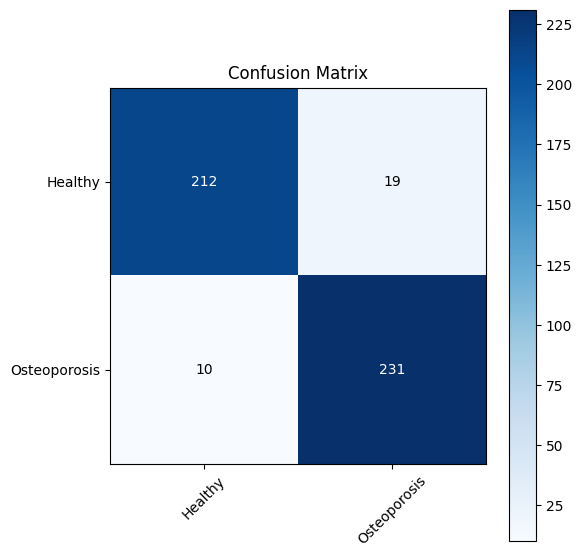

In [174]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from itertools import product

# Calculate the confusion matrix
cm = confusion_matrix(y_test, pred2)

# Assuming you have your actual labels and predicted values
true_labels = ['Healthy','Osteoporosis']

# Function to plot the confusion matrix
def plot_confusion_matrix(cm, labels):
  plt.figure(figsize=(6, 6))
  plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)  # Using 'Blues' colormap for heatmap
  plt.title('Confusion Matrix')
  plt.colorbar()
  tick_marks = np.arange(len(labels))
  plt.xticks(tick_marks, labels, rotation=45)
  plt.yticks(tick_marks, labels)

  # Set text for cells
  thresh = cm.max() / 2.
  for i, j in product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j],
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

  plt.grid(False)
  plt.tight_layout()
  plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, true_labels)